# IndiGo Expansion & Strategy Simulator



Goal:
Simulate strategic decisions and measure their impact on revenue, profit and network performance.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
indigo = pd.read_csv(
    "indigo_profitability.csv"
)

network = pd.read_csv(
    "indigo_network_intelligence.csv"
)

forecast = pd.read_csv(
    "indigo_forecast.csv"
)

In [3]:
print(indigo.shape)
print(network.shape)
print(forecast.shape)

(199, 36)
(35, 8)
(12, 4)


Scenario 1: Fuel Cost Increase

In [4]:
base_profit = indigo["Profit"].sum()

base_profit

np.int64(88239336920)

In [5]:
fuel_20 = indigo.copy()

fuel_20["Fuel_Cost"] = (
    fuel_20["Fuel_Cost"] * 1.20
)

In [6]:
fuel_20["Operating_Cost"] = (
    fuel_20["Fuel_Cost"]
    +
    fuel_20["Airport_Charges"]
    +
    fuel_20["Crew_Cost"]
    +
    fuel_20["Maintenance_Cost"]
) * fuel_20["Flights_Per_Year"]

In [7]:
fuel_20["Profit"] = (
    fuel_20["Revenue"]
    -
    fuel_20["Operating_Cost"]
)

In [8]:
fuel_profit = fuel_20["Profit"].sum()

print(
    "Base Profit:",
    round(base_profit/1e9,2),
    "B"
)

print(
    "New Profit:",
    round(fuel_profit/1e9,2),
    "B"
)

Base Profit: 88.24 B
New Profit: 54.28 B


Scenario 2: Ticket Price Increase

In [9]:
ticket_up = indigo.copy()

In [10]:
ticket_up["Avg_Ticket_Price"] = (
    ticket_up["Avg_Ticket_Price"] * 1.10
)

In [11]:
ticket_up["Revenue"] = (
    ticket_up["Passengers"]
    *
    ticket_up["Avg_Ticket_Price"]
    *
    ticket_up["Flights_Per_Year"]
)

In [12]:
ticket_up["Profit"] = (
    ticket_up["Revenue"]
    -
    ticket_up["Operating_Cost"]
)

In [13]:
ticket_profit = ticket_up["Profit"].sum()

print(
    "Profit After Ticket Increase:",
    round(ticket_profit/1e9,2),
    "B"
)

Profit After Ticket Increase: 125.25 B


Scenario 3: Load Factor Improvement

In [14]:
load_factor = indigo.copy()

In [15]:
load_factor["Load_Factor"] = np.minimum(
    load_factor["Load_Factor"] * 1.05,
    1
)

In [16]:
load_factor["Passengers"] = (
    load_factor["Aircraft_Capacity"]
    *
    load_factor["Load_Factor"]
).astype(int)

In [17]:
load_factor["Revenue"] = (
    load_factor["Passengers"]
    *
    load_factor["Avg_Ticket_Price"]
    *
    load_factor["Flights_Per_Year"]
)

In [18]:
load_factor["Profit"] = (
    load_factor["Revenue"]
    -
    load_factor["Operating_Cost"]
)

In [19]:
load_profit = (
    load_factor["Profit"].sum()
)

print(
    "Profit After Load Improvement:",
    round(load_profit/1e9,2),
    "B"
)

Profit After Load Improvement: 108.1 B


Scenario 4: New Route Launch

In [20]:
new_route_revenue = 2.5e9

new_route_cost = 1.8e9

new_route_profit = (
    new_route_revenue
    -
    new_route_cost
)

new_route_profit

700000000.0

In [21]:
print(
    "Expected New Route Profit:",
    round(new_route_profit/1e9,2),
    "B"
)

Expected New Route Profit: 0.7 B


Scenario 5: New Airport Addition

In [22]:
top_expansion = (
    network
    .sort_values(
        "Total_Profit",
        ascending=False
    )
    .tail(10)
)

top_expansion[
    [
        "Airport",
        "Total_Profit"
    ]
]

,Airport,Total_Profit
25,Muscat International Airport,296634770
26,Jaipur International Airport,209327865
27,Chandigarh Airport,-740338260
28,Lok Nayak Jayaprakash Airport,-983739970
29,Birsa Munda Airport,-1157123000
30,Singapore Changi Airport,-1342689365
31,Jammu Airport,-1659186340
32,Vishakhapatnam Airport,-2745061340
33,Tribhuvan International Airport,-3488462680
34,Trivandrum International Airport,-5743730885


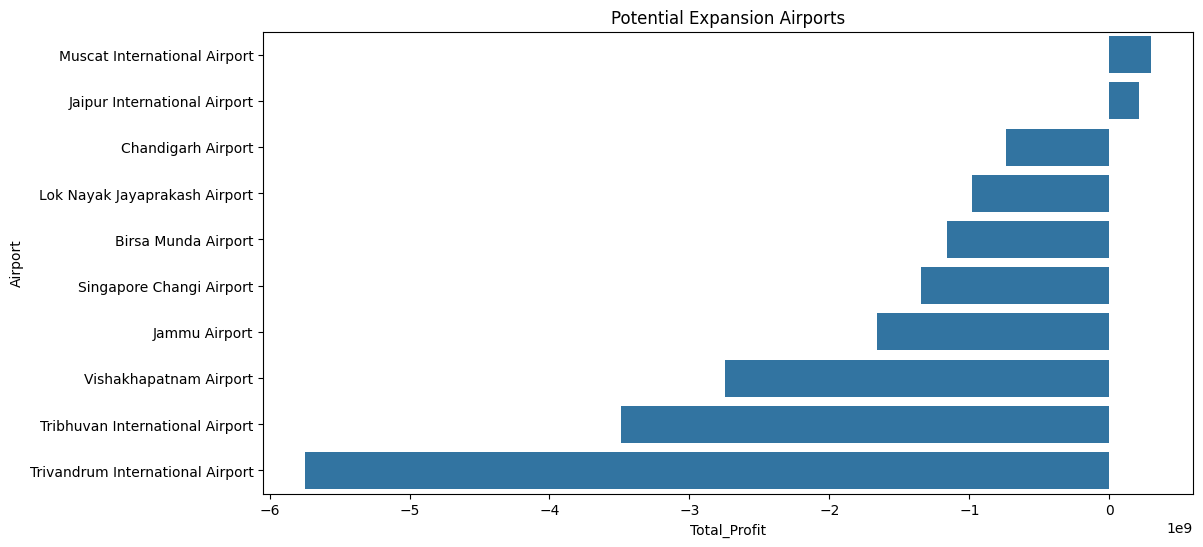

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_expansion,
    x="Total_Profit",
    y="Airport"
)

plt.title(
    "Potential Expansion Airports"
)

plt.show()

Scenario Comparison

In [24]:
scenario_results = pd.DataFrame({

    "Scenario":[
        "Current",
        "Fuel +20%",
        "Ticket +10%",
        "Load Factor +5%",
        "New Route"
    ],

    "Profit_Billion":[

        base_profit/1e9,

        fuel_profit/1e9,

        ticket_profit/1e9,

        load_profit/1e9,

        (base_profit+new_route_profit)/1e9
    ]
})

In [25]:
scenario_results

,Scenario,Profit_Billion
0,Current,88.239337
1,Fuel +20%,54.282479
2,Ticket +10%,125.247953
3,Load Factor +5%,108.096547
4,New Route,88.939337


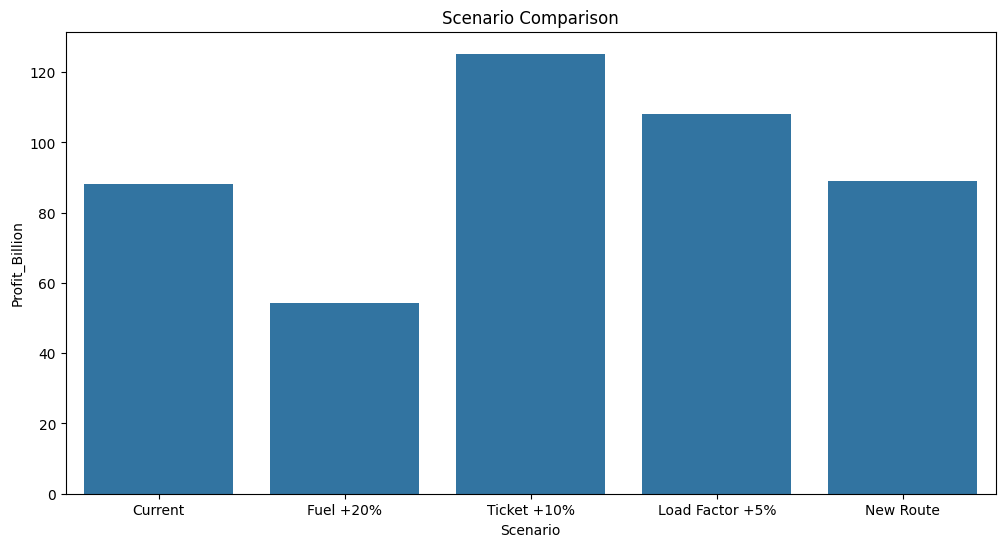

In [26]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=scenario_results,
    x="Scenario",
    y="Profit_Billion"
)

plt.title(
    "Scenario Comparison"
)

plt.show()

In [27]:
best_scenario = (
    scenario_results
    .sort_values(
        "Profit_Billion",
        ascending=False
    )
)

best_scenario

,Scenario,Profit_Billion
2,Ticket +10%,125.247953
3,Load Factor +5%,108.096547
4,New Route,88.939337
0,Current,88.239337
1,Fuel +20%,54.282479


In [28]:
print(
    "Best Scenario:"
)

print(
    best_scenario.iloc[0]["Scenario"]
)

Best Scenario:
Ticket +10%


In [29]:
recommendations = [

"Focus on high-profit hub airports",

"Improve load factor through route optimization",

"Expand routes from underutilized profitable airports",

"Monitor fuel price risk",

"Prioritize profitable domestic routes"
]

for r in recommendations:
    print("•", r)

• Focus on high-profit hub airports
• Improve load factor through route optimization
• Expand routes from underutilized profitable airports
• Monitor fuel price risk
• Prioritize profitable domestic routes


In [30]:
scenario_results.to_csv(
    "indigo_simulation_results.csv",
    index=False
)

print("Simulation Results Saved")

Simulation Results Saved


In [31]:
print("="*60)

print("INDIGO STRATEGY SIMULATION REPORT")

print("="*60)

print(
    "Current Profit:",
    round(base_profit/1e9,2),
    "B"
)

print(
    "Fuel Increase Profit:",
    round(fuel_profit/1e9,2),
    "B"
)

print(
    "Ticket Increase Profit:",
    round(ticket_profit/1e9,2),
    "B"
)

print(
    "Load Factor Improvement Profit:",
    round(load_profit/1e9,2),
    "B"
)

print()

print(
    "Best Scenario:"
)

print(
    best_scenario.iloc[0]["Scenario"]
)

print("="*60)

INDIGO STRATEGY SIMULATION REPORT
Current Profit: 88.24 B
Fuel Increase Profit: 54.28 B
Ticket Increase Profit: 125.25 B
Load Factor Improvement Profit: 108.1 B

Best Scenario:
Ticket +10%
